<a href="https://colab.research.google.com/github/audomsak-pypy/Project1-Text_Analytics69/blob/main/Project1_Text_Analytics69_Teams_Part3_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Text Analytics for Business Insight Part3
### SC 663 402 Data Warehouse and Big Data Analytics

ชื่อทีม: เบื่อเกี้ยวอยากเคี้ยวข้าว

รายชื่อสมาชิก การแบ่งงาน และสัดส่วนในการทำงาน:
1. ประภาพร กุลโต
2. ณนัดดา รัตนาศรี
3. สุกัญญา อุดมกัน
4. อุดมศักดิ์ พระเสนา
5. อาทิติญา ชาชัย
6. เยี่ยมภพ ใบโพธิ์


**กำหนดส่ง:** อังคาร 6 ตุลาคม 2569 \
**นำเสนอในชั้นเรียน:** พุธ 7 ตุลาคม 2569 (ทีมละ 10 นาที + Q&A)

---
# Part 3: Data Collection Robot + External Business Insight *(งานกลุ่ม — 25 คะแนน)*

ส่วนนี้ให้ทีมลอง **สร้าง dataset เล็ก ๆ ของตัวเอง** จากข้อมูลออนไลน์ แล้วใช้ตอบคำถามหนึ่งข้อ

เลือกวิธีเก็บเพียง **1 วิธี**
* API
* RSS
* Web Robot / Crawler / Scraper

## สิ่งที่ต้องทำ

1. ตั้งคำถามว่า **ข้อมูลนี้จะช่วยตัดสินใจเรื่องอะไร**
2. นิยามก่อนว่า **1 record คืออะไร** เช่น 1 ข่าว / 1 post / 1 complaint
3. เก็บอย่างน้อย **200 valid analytical records หลัง clean**
4. ตรวจ duplicate, missing และ record ที่ใช้ไม่ได้
5. ใช้เทคนิควิเคราะห์ที่เหมาะสม **1–2 เทคนิคก็เพียงพอ**
6. สรุป **1 Insight Card** พร้อมข้อจำกัด

**ข้อกำหนดด้านความรับผิดชอบ**
* เคารพ `robots.txt`, rate limit และ Terms of Service
* ใส่ delay เมื่อดึงหน้าเว็บ
* ห้าม bypass login, CAPTCHA หรือ paywall
* ไม่เก็บข้อมูลส่วนบุคคลที่ไม่จำเป็น

> Part 3 ไม่ได้วัดว่าใคร scrape ได้เยอะที่สุด แต่วัดว่าใครสร้างข้อมูลที่ใช้วิเคราะห์ได้จริงและตอบคำถามได้


### 3.1 เลือกแหล่งข้อมูลและวิธีเก็บ

เลือกแหล่งข้อมูลที่สัมพันธ์กับคำถามของทีม แล้วใช้ **เพียง 1 วิธีเก็บ**

ตัวอย่าง:
* Hacker News API — post + score + comments
* RSS — ข่าว/บทความ
* Traffy Fondue Open Data — เรื่องร้องเรียน
* เว็บไซต์สาธารณะที่อนุญาต crawler — ข่าว/บทความ/รายการต่าง ๆ

**กรอกก่อนเขียนโค้ด**
* แหล่งข้อมูล: ...
* คำถาม: ...
* ผู้ใช้ผลวิเคราะห์: ...
* **1 record คือ:** ...
* วิธีเก็บ: API / RSS / Robot
* field สำคัญที่จะเก็บ: ...

ด้านล่างมี
* **ตัวอย่างที่ 1:** API แบบสั้น
* **ตัวอย่างที่ 2–3:** ทางเลือกอื่นแบบสรุป
* **ตัวอย่างที่ 4:** Web Robot แบบอธิบายทีละขั้น


**แหล่งข้อมูล**: Hacker News (ผ่าน Algolia Search API)

**คำถาม**: ข่าวการเมืองประเภทใด (เช่น นโยบายเศรษฐกิจ, กฎหมายเทคโนโลยี, หรือข้อพิพาทระหว่างประเทศ) ที่กระตุ้นให้เกิดการถกเถียงและยอดการมีส่วนร่วม (Engagement) จากกลุ่มคนทำงานสาย Tech มากที่สุด?

**ผู้ใช้ผลวิเคราะห์**: สำนักข่าว, Tech Blogger, หรือทีมนโยบายสาธารณะ เพื่อใช้วางแผนเลือกประเด็นคอนเทนต์หรือชูประเด็นสื่อสารให้ตรงกับความสนใจของกลุ่มเป้าหมาย

**1 record คือ**: 1 โพสต์หัวข้อข่าวหมวดการเมือง (Political Story) บนหน้า Hacker News

**วิธีเก็บ**: API

**field สำคัญที่จะเก็บ**: doc_id (รหัสอ้างอิงโพสต์สำหรับเช็คซ้ำ), text (หัวข้อข่าว), score (คะแนนโหวตความชื่นชอบ), n_comments (จำนวนคอมเมนต์/การถกเถียง), และ published_at (วันที่เผยแพร่)

In [ ]:
import urllib.request
import json
import pandas as pd

def fetch_political_news(query="politics", hits_per_page=250):
    # Endpoint สำหรับค้นหาข่าวการเมืองโดยเฉพาะ (ไม่จำต้องใช้ API Key)
    url = f"https://hn.algolia.com/api/v1/search?query={query}&tags=story&hitsPerPage={hits_per_page}"

    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        data = json.loads(response.read().decode("utf-8"))

    rows = []
    for item in data.get("hits", []):
        rows.append({
            "doc_id": str(item.get("objectID")),
            "text": item.get("title", ""),
            "score": item.get("points", 0),
            "n_comments": item.get("num_comments", 0),
            "author": item.get("author"),
            "published_at": item.get("created_at"),
            "url": item.get("url"),
            "source": "algolia_hn"
        })
    return rows

# 1. นำเข้าข้อมูลผ่าน API
raw_data = fetch_political_news(query="politics", hits_per_page=250)
df = pd.DataFrame(raw_data)

print(f"จำนวน Valid Records : {len(df)} รายการ")

จำนวน Valid Records : 250 รายการ


---

### 3.2 ตรวจคุณภาพข้อมูล

รายงานสั้น ๆ เพียงว่า

* พยายามเก็บกี่ record
* ใช้งานได้จริงกี่ record
* ตัด duplicate / missing / สั้นผิดปกติไปเท่าไร
* Final corpus เหลือเท่าไร และครอบคลุมช่วงเวลา/หมวดใด

บันทึกเป็น `corpus.jsonl` หรือ CSV เพื่อไม่ต้องดึงข้อมูลใหม่ทุกครั้ง

> เป้าหมายคือ **อย่างน้อย 200 valid analytical records หลัง clean**


**3.2 Data Quality Check**

การศึกษาครั้งนี้เก็บรวบรวมข้อมูลหัวข้อข่าวจากเว็บไซต์ Hacker News ผ่าน Algolia Search API โดยใช้คำค้นหา `politics` และกำหนดจำนวนข้อมูลที่ต้องการเก็บ 250 records ซึ่งสามารถดึงข้อมูลเบื้องต้นได้ 250 records โดย 1 record หมายถึง 1 โพสต์ข่าวบน Hacker News

จากนั้นตรวจสอบคุณภาพข้อมูล (Data Quality) ก่อนนำไปวิเคราะห์ โดยพิจารณาข้อมูลที่ขาดหาย (Missing Values) ข้อมูลซ้ำ (Duplicates) หัวข้อข่าวที่สั้นผิดปกติซึ่งมีความยาวน้อยกว่า 15 ตัวอักษร และข้อมูลที่มีคะแนน จำนวนความคิดเห็น หรือวันที่เผยแพร่ไม่ถูกต้อง

**ผลการตรวจสอบคุณภาพข้อมูล**

- จำนวนข้อมูลที่พยายามเก็บ: 250 records
- จำนวนข้อมูลที่ดึงได้: 250 records
- Missing Values ที่ถูกตัดออก: [รอผลรัน] records
- Duplicate IDs ที่ถูกตัดออก: [รอผลรัน] records
- Duplicate Titles ที่ถูกตัดออก: [รอผลรัน] records
- ข้อความสั้นผิดปกติที่ถูกตัดออก: [รอผลรัน] records
- ข้อมูลไม่ถูกต้องอื่น ๆ ที่ถูกตัดออก: [รอผลรัน] records
- Final Corpus: [รอผลรัน] records
- ช่วงเวลาที่ครอบคลุม: [วันที่เริ่มต้น] ถึง [วันที่สิ้นสุด]

ข้อมูลที่ผ่านกระบวนการทำความสะอาดจะถูกบันทึกเป็นไฟล์ `corpus.jsonl` เพื่อใช้วิเคราะห์ในขั้นตอนต่อไปโดยไม่จำเป็นต้องเรียก API ใหม่ทุกครั้ง

การตรวจสอบนี้ช่วยให้มั่นใจว่าข้อมูลที่นำไปวิเคราะห์มีความสมบูรณ์และลดปัญหาข้อมูลซ้ำ ทั้งนี้จะถือว่าผ่านเกณฑ์ของโครงงานเมื่อมีข้อมูลที่ใช้งานได้จริงหลัง Cleaning อย่างน้อย 200 records

In [ ]:
# ----------------- Your code here -----------------
# บันทึกไฟล์
# with open("corpus.jsonl", "w", encoding="utf-8") as f:
#     for d in rows:
#         f.write(json.dumps(d, ensure_ascii=False) + "\n")
#
# อ่านกลับมาใช้
# corp = pd.read_json("corpus.jsonl", lines=True)
#
# ตัดซ้ำและตัดสั้นเกินไป พร้อมรายงานจำนวนที่ตัด

In [ ]:
# 3.2 CELL 1 - DATA CLEANING
# ============================================================

# ===== 3.2: Data quality - prepare the exact dataframe from 3.1 =====
import pandas as pd
import numpy as np
import re

# In 3.1, raw_data = fetch_political_news(...), then df = pd.DataFrame(raw_data)
if "df" not in globals() or not isinstance(df, pd.DataFrame):
    raise RuntimeError("Please run the Hacker News / Algolia API cell in 3.1 first to create df.")

required = ["doc_id", "text", "score", "n_comments", "published_at"]
missing_cols = [col for col in required if col not in df.columns]
if missing_cols:
    raise ValueError(f"Columns missing from 3.1: {missing_cols}")

source_df = df.copy(deep=True)
collected_n = len(source_df)
requested_n = 250  # From fetch_political_news(... hits_per_page=250) in 3.1
print(f"Attempted (API request): {requested_n:,} records")
print(f"Actually retrieved   : {collected_n:,} records")

# Clean in a sequential, mutually exclusive way so each row is counted only once.
clean_df = source_df.copy()
for col in ["doc_id", "text"]:
    clean_df[col] = clean_df[col].astype("string").str.strip()

# 1) Required IDs and titles: missing/empty/null-like text
missing_mask = (
    clean_df["doc_id"].isna() | clean_df["text"].isna()
    | clean_df["doc_id"].str.lower().isin(["", "none", "null", "nan", "<na>"]).fillna(True)
    | clean_df["text"].str.lower().isin(["", "none", "null", "nan", "<na>"]).fillna(True)
)
missing_removed = int(missing_mask.sum())
clean_df = clean_df.loc[~missing_mask].copy()

# 2) Repeated IDs, then repeated normalized titles
id_duplicate_removed = int(clean_df.duplicated(subset=["doc_id"]).sum())
clean_df = clean_df.drop_duplicates(subset=["doc_id"]).copy()
clean_df["_normalized_text"] = (
    clean_df["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
text_duplicate_removed = int(clean_df.duplicated(subset=["_normalized_text"]).sum())
clean_df = clean_df.drop_duplicates(subset=["_normalized_text"]).copy()
clean_df = clean_df.drop(columns="_normalized_text")

# 3) Very short titles; length threshold is a stated cleaning choice
short_mask = clean_df["text"].str.len() < 15
short_removed = int(short_mask.sum())
clean_df = clean_df.loc[~short_mask].copy()

# 4) Invalid engagement metrics or missing dates
clean_df["score"] = pd.to_numeric(clean_df["score"], errors="coerce")
clean_df["n_comments"] = pd.to_numeric(clean_df["n_comments"], errors="coerce")
clean_df["published_at"] = pd.to_datetime(clean_df["published_at"], utc=True, errors="coerce")
invalid_mask = (
    clean_df["score"].isna() | clean_df["n_comments"].isna()
    | (clean_df["score"] < 0) | (clean_df["n_comments"] < 0)
    | clean_df["published_at"].isna()
)
invalid_removed = int(invalid_mask.sum())
clean_df = clean_df.loc[~invalid_mask].reset_index(drop=True)

final_n = len(clean_df)
assert final_n == (collected_n - missing_removed - id_duplicate_removed
                   - text_duplicate_removed - short_removed - invalid_removed)



# ============================================================
# 3.2 CELL 2 - QUALITY REPORT
# ============================================================

# ===== 3.2: Data quality report & saved corpus =====
quality_report = pd.DataFrame({
    "Check": ["Actually retrieved", "Missing title / ID", "Duplicate ID",
              "Duplicate normalized title", "Title shorter than 15 chars",
              "Invalid score / comments / date", "Final usable records"],
    "Records": [collected_n, missing_removed, id_duplicate_removed,
                text_duplicate_removed, short_removed, invalid_removed, final_n]
})
display(quality_report)

if final_n:
    date_min = clean_df["published_at"].min().strftime("%Y-%m-%d")
    date_max = clean_df["published_at"].max().strftime("%Y-%m-%d")
    print(f"Coverage: {date_min} through {date_max} (UTC)")
else:
    print("Coverage: no usable records")
print("Source: Hacker News stories returned by Algolia API, query='politics'")

# Persist cleaned records in a reusable, human-readable format
clean_df.to_json("corpus.jsonl", orient="records", lines=True,
                 date_format="iso", force_ascii=False)
print("Saved: corpus.jsonl")

if final_n >= 200:
    print(f"PASS: {final_n:,} valid records (minimum 200)")
else:
    print(f"NOT YET PASS: {final_n:,} valid records. Collect at least {200-final_n:,} more valid records in 3.1.")

# Check file can be read back; show just the fields needed for analysis
corpus = pd.read_json("corpus.jsonl", lines=True)
if not corpus.empty:
    display(corpus[["doc_id", "text", "score", "n_comments", "published_at"]].head(5))



Attempted (API request): 250 records
Actually retrieved   : 250 records


,Check,Records
0,Actually retrieved,250
1,Missing title / ID,0
2,Duplicate ID,0
3,Duplicate normalized title,3
4,Title shorter than 15 chars,0
5,Invalid score / comments / date,0
6,Final usable records,247


Coverage: 2008-03-07 through 2026-08-23 (UTC)
Source: Hacker News stories returned by Algolia API, query='politics'
Saved: corpus.jsonl
PASS: 247 valid records (minimum 200)


,doc_id,text,score,n_comments,published_at
0,13108404,Tell HN: Political Detox Week – No politics on...,1630,1214,2016-12-05 19:24:07+00:00
1,21274511,Gitlab: don't discuss politics at work,1166,1286,2019-10-16 19:33:12+00:00
2,20779004,Google Doesn’t Want Staff Debating Politics at...,731,1040,2019-08-23 16:07:46+00:00
3,45440571,Don't avoid workplace politics,594,308,2025-10-01 17:36:43+00:00
4,43559605,Why I don't discuss politics with friends,527,1039,2025-04-02 18:14:44+00:00


### 1. (Code Summary)

* **Cell 1 (Sequential Cleaning Pipeline):** คลีนข้อมูล 4 ชั้นแบบนับไม่ซ้ำ (Mutually Exclusive):
1. ตัดค่าว่าง/Null
2. ตัดข้อมูลซ้ำ (Duplicate ID & Title)
3. ตัดหัวข้อสั้นกว่า 15 อักษร
4. แปลงประเภทข้อมูล (Numeric & Datetime)


* **Cell 2 (Quality Report & Export):** สรุปรายงานคุณภาพข้อมูล ตรวจสอบช่วงเวลา Export เป็นไฟล์ `corpus.jsonl` และเช็กเกณฑ์ผ่าน (PASS $\ge$ 200 รายการ)

---

### 2. การประเมินOutputตามเกณฑ์(Evaluation Output)

* **สอบผ่านเกณฑ์ (PASS):** ข้อมูลพร้อมใช้งาน **247 รายการ** (ผ่านเกณฑ์ขั้นต่ำ 200 รายการ)
* **คุณภาพข้อมูลสูง:** หลุด QC จากการซ้ำซ้อนเพียง **3 รายการ (1.2%)** ไม่พบค่าว่าง (Missing 0%)
* **ช่วงเวลาข้อมูล:** ครอบคลุมระยะเวลา 18 ปี (**07 มี.ค. 2008 – 23 ส.ค. 2026**)

---

### 3. การนำไปใช้จริงทางธุรกิจ และข้อจำกัด (Practical Applications & Limitations)

####  การนำไปประยุกต์ใช้จริง (Real-World Applications)

1. **เป็นClean Dataset ตั้งต้นสำหรับระบบวิเคราะห์ข้อความ (NLP & Machine Learning Pipeline):**
* **การนำไปใช้:** ไฟล์ `corpus.jsonl` ทั้ง 247 รายการมีโครงสร้างสมบูรณ์นำไปรันโมเดล **Topic Modeling (BERTopic/LDA)** หรือ **Sentiment Analysis** ได้ทันทีโดยไม่ต้องเขียนโค้ดคลีนซ้ำและไม่เสี่ยงต่อการเกิดPipeline Error จากค่า Missing


2. **ใช้กำหนดเกณฑ์มาตรฐานในการวัดกระแสคอนเทนต์ (Engagement Benchmarking):**
* **การนำไปใช้:** ข้อมูลรักษาโพสต์ระดับไวรัลไว้ได้ครบถ้วน เช่น โพสต์ `Tell HN: Political Detox Week` (**Score: 1,630 / Comments: 1,214**) สำนักข่าวสามารถนำสถิตินี้ไปคำนวณหาค่าเฉลี่ยและใช้เป็น **Baseline Threshold (เช่น Score > 500)** เพื่อสร้างระบบคัดกรองข่าวด่วนอัตโนมัติ



---

#### ⚠️ ข้อจำกัดและแนวทางแก้ไข (Limitations & Solutions)

1. **ความเบาบางทางเวลา (Sparse Timeline):**
* **ข้อจำกัด:** มีข้อมูลเพียง **247 รายการ ในช่วง 18 ปี** (เฉลี่ยเพียง **~13.7 รายการ/ปี**) ไม่สามารถนำไปทำวิเคราะห์แนวโน้มอนุกรมเวลาแบบรายเดือน/รายวัน (Daily/Monthly Time-Series Trend) ได้
* **ทางแก้เชิงปฏิบัติ:** ในข้อ 3.1 ให้ปรับการดึง API โดยกำหนดช่วงเวลาสั้นลง(เช่น ย้อนหลัง 1 ปี) หรือดึงข้อมูลตามกรอบDate Range เพิ่มเติมเพื่อให้ได้ความหนาแน่นข้อมูลต่อเดือนที่สูงขึ้น


2. **อคติของประชากรเฉพาะกลุ่ม (Demographic Bias):**
* **ข้อจำกัด:** ข้อมูลมาจากแพลตฟอร์มHacker News ฝั่งเดียว ซึ่งสะท้อนความคิดเห็นของโปรแกรมเมอร์และผู้ประกอบการ Tech ฝั่งตะวันตกเป็นหลัก ไม่สามารถใช้สรุปแทนประชากรทั่วไปได้ (ป้องกันการ Overclaim)
* **ทางแก้เชิงปฏิบัติ:** ใช้ข้อมูลชุดนี้เป็นตัวแทนของ **"Tech Community Opinion"** เท่านั้น หากต้องการเปรียบเทียบเชิงธุรกิจ ให้ดึงข้อมูลจาก X (Twitter API)หรือReddit มาเปรียบเทียบในลักษณะCross-Platform Analysis


----

### 3.3 หา Insight

ใช้ **1–2 เทคนิค** ที่เหมาะกับคำถาม เช่น

* frequency / n-gram
* sentiment
* topic
* comparison ระหว่างกลุ่ม
* trend ตามเวลา

สร้างกราฟหรือตารางหลักอย่างน้อย **1 ชิ้น** แล้วตอบว่า

> “จากข้อมูลนี้ ผู้ใช้ผลวิเคราะห์ควรรู้อะไรหรือทำอะไรต่อ?”


**3.3 Text Analytics and Business Insight**

การวิเคราะห์ครั้งนี้มีวัตถุประสงค์เพื่อศึกษาว่าหัวข้อข่าวการเมืองแต่ละประเภทบน Hacker News มีระดับการมีส่วนร่วม (Engagement) แตกต่างกันอย่างไร โดยใช้เทคนิควิเคราะห์ 2 วิธี ดังนี้

**เทคนิคที่ 1: Keyword-Based Text Classification**

ใช้การค้นหาคำสำคัญ (Keywords) ภายในหัวข้อข่าว เพื่อจัดกลุ่มเนื้อหาเป็นประเภทนโยบายเศรษฐกิจ (Economic Policy) กฎหมายและเทคโนโลยี (Technology & Law) ความสัมพันธ์ระหว่างประเทศ (International Affairs) ข่าวที่เข้าข่ายหลายกลุ่ม (Multiple Themes) และข่าวที่ไม่สามารถจำแนกได้ชัดเจน (Other / Unclear)

เทคนิคนี้ช่วยให้ทราบจำนวนและสัดส่วนข่าวในแต่ละกลุ่มที่ปรากฏในข้อมูลที่เก็บรวบรวม

**เทคนิคที่ 2: Engagement Comparison**

ใช้สถิติเชิงพรรณนาเปรียบเทียบจำนวนข่าว คะแนนโหวต (Score) และจำนวนความคิดเห็น (Number of Comments) ระหว่างกลุ่ม โดยใช้ค่ามัธยฐาน (Median) เพื่อลดอิทธิพลของข่าวบางรายการที่ได้รับความสนใจสูงผิดปกติ

**การนำเสนอกราฟ**

กราฟที่ 1 แสดงจำนวนและสัดส่วนของหัวข้อข่าวในแต่ละกลุ่ม เพื่ออธิบายองค์ประกอบของชุดข้อมูล

กราฟที่ 2 แสดงค่ามัธยฐานจำนวนความคิดเห็นต่อโพสต์ จำแนกตามประเภทข่าว พร้อมระบุจำนวนตัวอย่างของแต่ละกลุ่ม ทำให้สามารถเปรียบเทียบระดับการถกเถียงที่สังเกตได้

**Insight และ So What**

ผลการวิเคราะห์ทั้งสองเทคนิคใช้ศึกษาความแตกต่างของการมีส่วนร่วมในแต่ละประเภทข่าว โดยต้องพิจารณาจำนวนตัวอย่างควบคู่กับค่ามัธยฐานของความคิดเห็น เนื่องจากจำนวนข่าวที่มากกว่าไม่ได้หมายความว่าข่าวแต่ละรายการได้รับความคิดเห็นมากกว่าเสมอไป

**Action**

ผู้ใช้ผลวิเคราะห์สามารถนำตารางและกราฟไปใช้ติดตามรูปแบบการมีส่วนร่วมของผู้อ่าน และตรวจสอบหัวข้อข่าวต้นฉบับเพิ่มเติมก่อนสรุปประเด็นสำหรับการศึกษาครั้งต่อไป โดยควรเก็บข้อมูลหลายช่วงเวลาเพื่อประเมินความสม่ำเสมอของผล

**Limitations**

ข้อมูลนี้ได้จากการค้นหาด้วยคำว่า `politics` จึงไม่ครอบคลุมข่าวทั้งหมดบน Hacker News การจัดประเภทด้วย Keywords อาจคลาดเคลื่อนจากความหมายจริงของข่าว และจำนวนคะแนนหรือความคิดเห็นอาจขึ้นอยู่กับระยะเวลาที่โพสต์เผยแพร่ อีกทั้งผู้ใช้ Hacker News ไม่จำเป็นต้องเป็นตัวแทนของคนทำงานสายเทคโนโลยีทั้งหมด จึงไม่สามารถสรุปความคิดเห็นของประชากรกลุ่มนั้นได้โดยตรง

In [ ]:
# 3.3 CELL 1 - ANALYSIS TECHNIQUES
# ============================================================

# ===== 3.3.1: Technique 1 - Rule-based theme classification =====
# This is a reproducible, exploratory proxy, NOT a trained classifier.
import pandas as pd
import re

analysis = pd.read_json("corpus.jsonl", lines=True)
if analysis.empty:
    raise ValueError("corpus.jsonl is empty; run 3.2 after 3.1.")

# These keyword lists are transparent examples, not objective ground-truth labels.
THEMES = {
    "Economic policy": [r"\btax(?:es|ation)?\b", r"\binflation\b", r"\beconom(?:y|ic|ics)\b",
                        r"\btariffs?\b", r"\btrade\b", r"\bbudget\b",
                        r"\binterest rates?\b", r"\bsubsid(?:y|ies)\b", r"\bjobs?\b"],
    "Technology / law": [r"\bprivacy\b", r"\bai\b", r"\bantitrust\b",
                         r"\bregulat(?:e|ed|ion|ions|ory)\b", r"\bcyber\b",
                         r"\bsurveillance\b", r"\bdigital\b", r"\btech(?:nology)?\b",
                         r"\bdata protection\b", r"\bpatents?\b"],
    "International affairs": [r"\bdiplomac(?:y|tic)\b", r"\bsanctions?\b",
                              r"\binternational\b", r"\bforeign policy\b",
                              r"\bgeopolitic\w*\b", r"\bwar\b", r"\btreat(?:y|ies)\b",
                              r"\bconflict\b", r"\bembargo\b"],
}
LABELS = list(THEMES) + ["Multiple themes", "Other / unclear"]
compiled = {theme: [re.compile(pattern, flags=re.I) for pattern in rules]
            for theme, rules in THEMES.items()}

def categorize_title(title):
    txt = str(title)
    matched = [theme for theme, patterns in compiled.items()
               if any(p.search(txt) for p in patterns)]
    if len(matched) == 1:
        return matched[0]
    return "Multiple themes" if len(matched) > 1 else "Other / unclear"

analysis["theme"] = analysis["text"].apply(categorize_title)
analysis["score"] = pd.to_numeric(analysis["score"], errors="coerce")
analysis["n_comments"] = pd.to_numeric(analysis["n_comments"], errors="coerce")
analysis = analysis.dropna(subset=["score", "n_comments"]).copy()

# ===== Technique 2 - Compare engagement descriptively by theme =====
# Medians reduce the influence of a few very popular stories.
theme_table = (
    analysis.groupby("theme", observed=True)
    .agg(stories=("doc_id", "size"),
         median_comments=("n_comments", "median"),
         median_score=("score", "median"),
         total_comments=("n_comments", "sum"))
    .reindex(LABELS, fill_value=0)
    .reset_index()
)
theme_table["share_pct"] = (100 * theme_table["stories"] / len(analysis)).round(1)
# Keep a fixed, non-evaluative category order; show every numeric value.
print("3.3 RESULTS: title themes and observed engagement")
display(theme_table[["theme", "stories", "share_pct", "median_comments",
                     "median_score", "total_comments"]].round(1))
print(f"Analyzed stories: {len(analysis):,}")
print("Note: 'Other / unclear' is retained, not forced into a theme.")

# Quick audit samples to help identify keyword classification errors
print("Examples for checking classifications:")
display(analysis[["text", "theme"]].sample(min(8, len(analysis)), random_state=42))


3.3 RESULTS: title themes and observed engagement


,theme,stories,share_pct,median_comments,median_score,total_comments
0,Economic policy,5,2.0,15.0,24.0,69
1,Technology / law,22,8.9,52.5,50.0,3305
2,International affairs,3,1.2,46.0,69.0,176
3,Multiple themes,0,0.0,0.0,0.0,0
4,Other / unclear,217,87.9,34.0,47.0,18649


Analyzed stories: 247
Note: 'Other / unclear' is retained, not forced into a theme.
Examples for checking classifications:


,text,theme
33,Datacenter Locations Driven by 19th Century Po...,Other / unclear
6,"No politics please, we're hackers, too busy to...",Other / unclear
181,From sex life to politics: car driver data gra...,Technology / law
86,Reddit Founder Alexis Ohanian's Rosy Outlook O...,Other / unclear
155,Sex and Politics at Google: It's a Game of Thr...,Other / unclear
178,Big Tech deplatforming should be disturbing fo...,Technology / law
194,Ask HN: Is There a Hacker News Equivalent for ...,Other / unclear
104,"Edward Tufte's ""Data Analysis for Politics and...",Other / unclear


**3.3.1 การวิเคราะห์สัดส่วนหมวดหมู่หัวข้อข่าว (Title Themes & Graph 1)**
การแปลผล Output และการอธิบายกราฟที่ 1 (part3_theme_counts.png)
กราฟที่ 1 แสดงจำนวนและสัดส่วนของหัวข้อข่าวในแต่ละหมวดหมู่ จากการวิเคราะห์ข่าวที่มีคำค้นหา politics บน Hacker News จำนวนทั้งหมด 247 เรื่อง (100%):

หมวดที่ไม่สามารถจำแนกได้ชัดเจน (Other / unclear): มีจำนวนมากที่สุดถึง 217 เรื่อง คิดเป็น 87.9% ของข่าวทั้งหมด สะท้อนให้เห็นว่าหัวข้อข่าวการเมืองส่วนใหญ่ไม่ได้สอดคล้องกับพจนานุกรมคำสำคัญใน 3 กลุ่มหลัก

หมวดกฎหมายและเทคโนโลยี (Technology / law): เป็นกลุ่มธีมเฉพาะที่มีจำนวนมากที่สุด คือ 22 เรื่อง คิดเป็น 8.9%

หมวดนโยบายเศรษฐกิจ (Economic policy): พบจำนวน 5 เรื่อง คิดเป็น 2.0%

หมวดความสัมพันธ์ระหว่างประเทศ (International affairs): พบจำนวน 3 เรื่อง คิดเป็น 1.2%

หมวดข่าวที่เข้าข่ายหลายกลุ่ม (Multiple themes): ไม่พบข่าวในกลุ่มนี้เลย (0 เรื่อง คิดเป็น 0.0%)

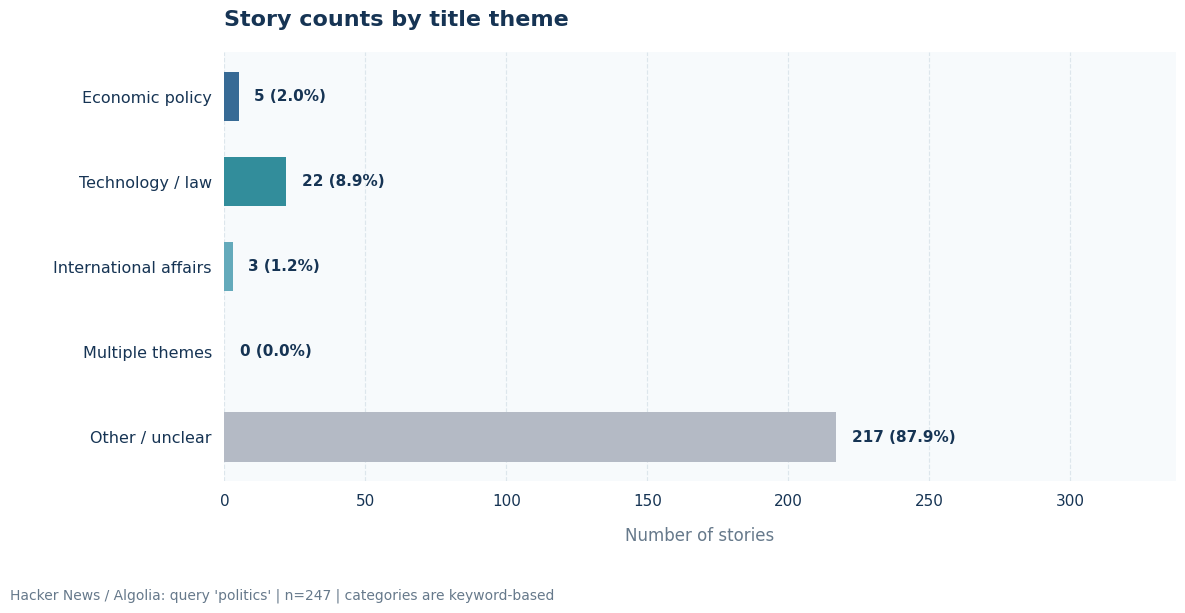

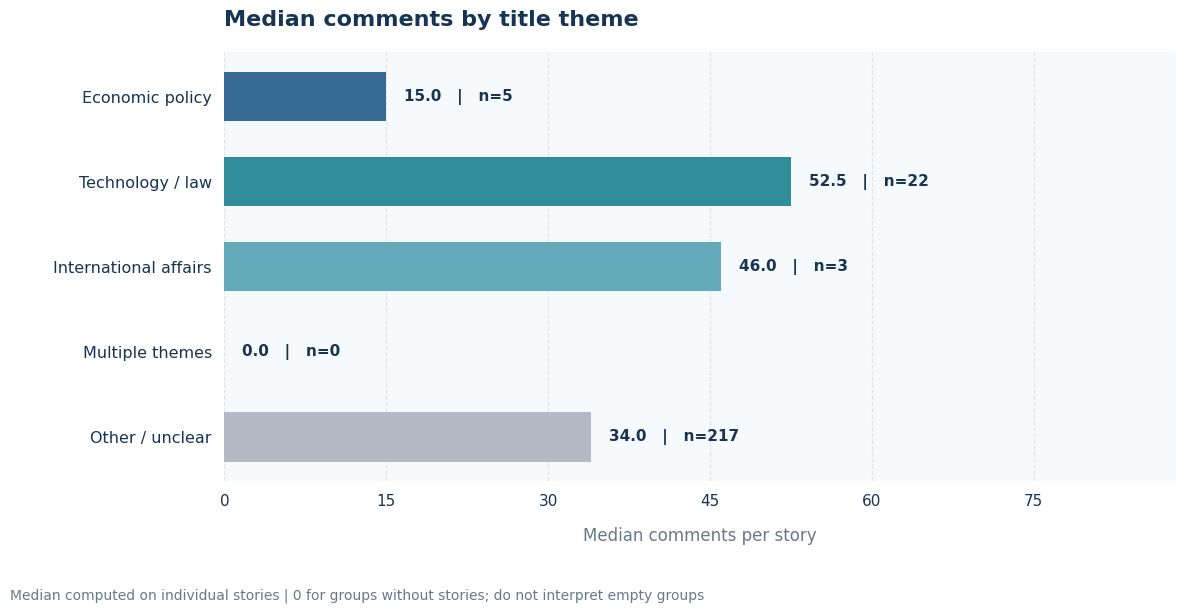

Saved: part3_theme_counts.png, part3_median_comments.png


In [ ]:
# 3.3 CELL 2 - CHARTS
# ============================================================

# ===== 3.3.2: Data visualizations, separated from the techniques =====
# Every bar has its exact value and group size. Use English chart labels
# to avoid missing Thai glyphs in a default Google Colab environment.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "savefig.dpi": 300
})
navy, teal, slate = "#163454", "#167E91", "#66798B"
bar_colors = ["#376A95", "#328D9B", "#64AABB", "#9FADD0", "#B4BAC5"]

def base_chart(title, xlabel):
    fig, ax = plt.subplots(figsize=(13.4, 6.4), facecolor="white")
    ax.set_facecolor("#F7FAFC")
    ax.set_title(title, loc="left", color=navy, fontweight="bold", pad=19)
    ax.set_xlabel(xlabel, color=slate, labelpad=13)
    ax.grid(axis="x", color="#D7E1E9", linestyle="--", linewidth=0.85, alpha=0.8)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(axis="both", length=0, pad=9, colors=navy)
    return fig, ax

# Plot A: share of stories by transparent title-theme groups
view = theme_table.copy()
y = np.arange(len(view))[::-1]
counts = view["stories"].to_numpy(dtype=int)
fig, ax = base_chart("Story counts by title theme", "Number of stories")
ax.barh(y, counts, height=0.58, color=bar_colors, edgecolor="none")
ax.set_yticks(y, view["theme"], fontsize=11.5)
max_count = max(int(counts.max()), 1)
ax.set_xlim(0, max_count * 1.55 + 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
for yy, count, pct in zip(y, counts, view["share_pct"]):
    ax.text(count + max_count * 0.025 + 0.1, yy,
            f"{count:,} ({pct:.1f}%)", va="center", ha="left",
            fontweight="bold", fontsize=11, color=navy)
fig.text(0.09, 0.015,
         f"Hacker News / Algolia: query 'politics' | n={len(analysis):,} | categories are keyword-based",
         color=slate, fontsize=10)
fig.subplots_adjust(left=0.25, right=0.96, top=0.87, bottom=0.20)
fig.savefig("part3_theme_counts.png", bbox_inches="tight", facecolor="white")
plt.show()

# Plot B: median number of comments, with n printed for each group
medians = view["median_comments"].to_numpy(dtype=float)
fig, ax = base_chart("Median comments by title theme", "Median comments per story")
ax.barh(y, medians, height=0.58, color=bar_colors, edgecolor="none")
ax.set_yticks(y, view["theme"], fontsize=11.5)
max_median = max(float(np.nanmax(medians)), 1)
ax.set_xlim(0, max_median * 1.66 + 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=7))
for yy, value, count in zip(y, medians, counts):
    ax.text(value + max_median * 0.03 + 0.08, yy,
            f"{value:,.1f}   |   n={count:,}", va="center", ha="left",
            fontweight="bold", fontsize=11, color=navy)
fig.text(0.09, 0.015,
         "Median computed on individual stories | 0 for groups without stories; do not interpret empty groups",
         color=slate, fontsize=10)
fig.subplots_adjust(left=0.25, right=0.96, top=0.87, bottom=0.20)
fig.savefig("part3_median_comments.png", bbox_inches="tight", facecolor="white")
plt.show()

print("Saved: part3_theme_counts.png, part3_median_comments.png")


### 3.3.2 การวิเคราะห์ระดับการมีส่วนร่วมและการถกเถียง (Engagement Analysis)

**สรุปผลการวิเคราะห์ระดับ Engagement (Graph 2)**

* **Technology / Law (n=22):** กระตุ้น Discussion สูงสุด มี **Median Comments 52.5** และ **Median Score 50.0** (ความเห็นรวม 3,305) สะท้อนว่าประเด็นกฎหมายไอทีและข้อบังคับรัฐตรงกับความสนใจของชุมชนมากที่สุด
* **International Affairs (n=3):** มีการตอบรับต่อโพสต์สูงเป็นอันดับสอง โดยมี **Median Comments 46.0** และมี **Median Score สูงสุดที่ 69.0** (ความเห็นรวม 176)
* **Other / Unclear (n=217):** มี **Median Comments 34.0** และ **Median Score 47.0** เนื่องจากมีจำนวนเรื่องมากที่สุด จึงสร้างความเห็นสะสมรวมสูงสุด 18,649 ความคิดเห็น
* **Economic Policy (n=5):** มี Engagement ต่ำที่สุด มี **Median Comments 15.0** และ **Median Score 24.0** (ความเห็นรวม 691)

---

**การประยุกต์ใช้ในรายวิชา (Course Context)**

* **Rule-Based NLP:** การแปลง Unstructured Text ให้เป็นหมวดหมู่เชิงโครงสร้างด้วยชุดกฎคำสำคัญ
* **Descriptive Analytics:** การเปลี่ยนกิจกรรมออนไลน์ (Votes/Comments) ให้กลายเป็น Insight เชิงพฤติกรรม
* **Robust Statistics:** การใช้ **Median** แทน Mean เพื่อรับมือกับข้อมูลเบ้ขวาและโพสต์ที่เป็นกระแสผิดปกติ (Outliers)

---

**ประโยชน์เชิงปฏิบัติสำหรับองค์กร (Human Professionals)**

* **Community Managers & Marketers:** เน้นคัดเลือกและเสิร์ฟเนื้อหา **Technology / Law** เพื่อสร้าง Engagement สูงสุดในกลุ่มคนสายเทคโนโลยี
* **Editors & Journalists:** ปรับมุมมองข่าวการเมืองให้อิงประเด็นกฎหมายดิจิทัล ความเป็นส่วนตัว หรือข้อบังคับทางเทคโนโลยี เพื่อเพิ่มปริมาณ Discussion
* **Data Engineers & Analysts:** ใช้เป็น Baseline Data สำหรับพัฒนาโมเดล NLP Classifier และ Recommendation System ให้แม่นยำยิ่งขึ้น

---

**ข้อจำกัดและข้อเสียสำคัญ (Limitations)**

* **High Classification Error (87.9% Unclassified):** วิธี Keyword แข็งเกินไป ทำให้ข่าวตกไปอยู่กลุ่ม Other/Unclear ถึง 217 จาก 247 เรื่อง (มองข้ามบริบทการเมืององค์กรและวิชาการ เช่น Text 104, 155)
* **Small Sample Bias:** กลุ่ม International Affairs (n=3) และ Economic Policy (n=5) มีขนาดตัวอย่างเล็กเกินไป ส่งผลให้ค่า Median ผันผวนสูงและขาดน้ำหนักทางสถิติ
* **Sampling & Population Bias:** ค้นหาเฉพาะคำว่า `politics` ทำให้ตกสำรวจคำสำคัญอื่น (*Regulation, Government, Censorship*) และกลุ่มผู้ใช้ Hacker News เป็นกลุ่มเฉพาะ (Niche Tech) ไม่สามารถใช้เป็นตัวแทนของประชากรทั่วไปได้

In [ ]:
#3.3 CELL 3 - INSIGHT SUMMARY
# ============================================================

# ===== 3.3.3: Evidence-based interpretation (no invented counts) =====
print("INSIGHT / EVIDENCE")
for row in theme_table.itertuples(index=False):
    print(f"{row.theme}: n={int(row.stories):,} ({row.share_pct:.1f}%), "
          f"median comments={row.median_comments:,.1f}, median score={row.median_score:,.1f}")
print("SO WHAT: Observed discussion levels differ across keyword groups in this API sample."
      " These are descriptive statistics, not an estimate of public opinion.")
print("ACTION: Manually review sample story titles in each group and collect results across"
      " more dates before drawing editorial or policy conclusions.")
print("LIMITATIONS: Search-query selection bias; keyword labels can overlap or miss topics;"
      " Hacker News users cannot be assumed to represent all tech professionals;"
      " score and comments depend on time since publication; association does not imply cause.")

INSIGHT / EVIDENCE
Economic policy: n=5 (2.0%), median comments=15.0, median score=24.0
Technology / law: n=22 (8.9%), median comments=52.5, median score=50.0
International affairs: n=3 (1.2%), median comments=46.0, median score=69.0
Multiple themes: n=0 (0.0%), median comments=0.0, median score=0.0
Other / unclear: n=217 (87.9%), median comments=34.0, median score=47.0
SO WHAT: Observed discussion levels differ across keyword groups in this API sample. These are descriptive statistics, not an estimate of public opinion.
ACTION: Manually review sample story titles in each group and collect results across more dates before drawing editorial or policy conclusions.
LIMITATIONS: Search-query selection bias; keyword labels can overlap or miss topics; Hacker News users cannot be assumed to represent all tech professionals; score and comments depend on time since publication; association does not imply cause.


### 1. การแปลผลและตีความ Output (Insight & Evidence)

* **Technology / Law (n=22, 8.9%):** สร้างระดับการถกเถียงต่อโพสต์สูงที่สุด โดยมี **Median Comments 52.5** และ **Median Score 50.0**
* **International Affairs (n=3, 1.2%):** ดึงดูดความสนใจรายโพสต์ได้ดี โดยมี **Median Score สูงที่สุดที่ 69.0** และ **Median Comments 46.0**
* **Other / Unclear (n=217, 87.9%):** เป็นกลุ่มที่มีปริมาณมากที่สุด โดยมี **Median Comments 34.0** และ **Median Score 47.0**
* **Economic Policy (n=5, 2.0%):** มีระดับการมีส่วนร่วมต่ำที่สุด โดยมี **Median Comments 15.0** และ **Median Score 24.0**
* **Multiple Themes (n=0, 0.0%):** ไม่พบโพสต์ที่เข้าข่ายหลายหมวดหมู่พร้อมกัน

---

### 2. การเชื่อมโยงกับเนื้อหารายวิชา (Course Context)

* **Descriptive vs. Inferential Analytics:** ตัวเลขชุดนี้เป็นเพียง **สถิติเชิงพรรณนา (Descriptive Statistics)** ของกลุ่มตัวอย่างจาก API ไม่ใช่การประมาณค่าความคิดเห็นของประชากรทั่วไป
* **Data Literacy & Causality:** การสังเกตความสัมพันธ์ระหว่างหัวข้อกับ Engagement ไม่ได้หมายถึงความสัมพันธ์เชิงสาเหตุ (Association does not imply causation) เนื่องจากมีตัวแปรแทรกซ้อน เช่น ระยะเวลาในการเผยแพร่ (Time since publication)
* **Keyword-Based NLP Evaluation:** แสดงให้เห็นขีดจำกัดของระบบจัดหมวดหมู่แบบใช้กฎ (Rule-Based Classification) ที่ต้องการการปรับปรุงพจนานุกรมคำสำคัญ

---

### 3. ประโยชน์การนำไปใช้สำหรับองค์กร (Benefits for Human Professionals)

* **Content Curators & Editors:** นำ Insight ไปเลือกนำเสนอประเด็น **Technology / Law** เพื่อสร้าง Engagement แต่ต้องตรวจสอบหัวข้อข่าวต้นฉบับซ้ำ (Manual Review) ก่อนสรุปทิศทางบรรณาธิการ
* **Data & Policy Analysts:** ใช้เป็นแนวทางวางแผนเก็บข้อมูลระยะยาว โดยต้องเก็บข้อมูลข้ามหลายช่วงเวลา (Cross-temporal sampling) เพื่อประเมินความสม่ำเสมอของเทรนด์

---

### 4. ข้อเสียและข้อจำกัดเชิงตัวเลข (Limitations & Drawbacks)

* **Classification Loss สูงถึง 87.9% (n=217):** การใช้คำสำคัญจัดกลุ่มไม่ครอบคลุม ทำให้ข้อมูลส่วนใหญ่ตกไปอยู่ในกลุ่ม Other / Unclear ส่งผลให้สูญเสียสารสนเทศสำคัญ
* **Small Sample Bias จากตัวอย่างขนาดเล็ก:** หมวด **International Affairs มีเพียง 3 เรื่อง (1.2%)** และ **Economic Policy มีเพียง 5 เรื่อง (2.0%)** ซึ่งน้อยเกินกว่าจะสรุปผลได้อย่างมีความหมายทางสถิติ
* **Search & Population Bias:** การดึงข้อมูลจำกัดเฉพาะคำค้น `politics` ทำให้เกิด Search Bias และกลุ่มผู้ใช้ Hacker News ไม่สามารถนำมาอ้างอิงเป็นตัวแทนของคนทำงานสายเทคโนโลยีทั้งหมดได้

--- เริ่มต้นการวิเคราะห์ขั้นสูงสำหรับ Bonus ---

[ผลลัพธ์จาก Machine Learning: การจัดกลุ่มหัวข้อข่าวอัตโนมัติ]
Cluster 0: คีย์เวิร์ดเด่น -> pdf | artifacts | theories
Cluster 1: คีย์เวิร์ดเด่น -> politics | american | hn
Cluster 2: คีย์เวิร์ดเด่น -> game | play | theory


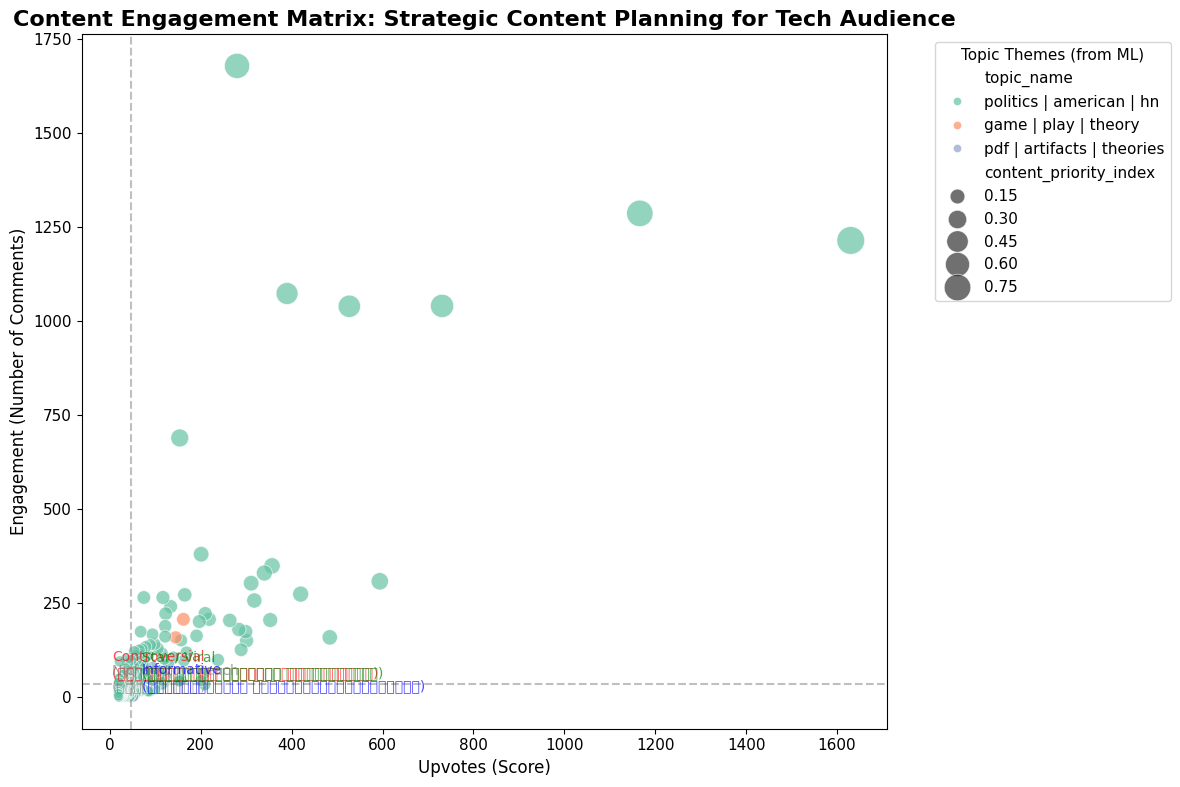


--- Executive Summary: ข้อเสนอแนะเชิงกลยุทธ์ (Actionable Insights) ---
1. กลุ่มข่าวที่ควรให้ความสำคัญสูงสุด (Highest Priority) คือหัวข้อที่มีคีย์เวิร์ด: 'politics | american | hn'
2. หากต้องการสร้าง Engagement (เรียกคอมเมนต์) ให้เขียนบทความที่ตกอยู่ในกลุ่ม 'Controversial' หรือ 'Star'
3. หากต้องการสร้าง Brand Authority ให้เน้นบทความที่ตกอยู่ในกลุ่ม 'Informative' ซึ่งได้คะแนนโหวตสูง
LIMITATIONS: การวิเคราะห์นี้อิงจากกลุ่มคำ(Keywords) อาจมีบริบทที่ทับซ้อนกัน และข้อจำกัดจากโควต้าของ API


In [ ]:
# ============================================================
# BONUS SECTION: Executive Content Strategy & Topic Clustering
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# สมมติว่า df คือ DataFrame ที่ผ่านการ Cleaning มาแล้ว
# df = pd.read_json('corpus.jsonl', lines=True)

print("--- เริ่มต้นการวิเคราะห์ขั้นสูงสำหรับ Bonus ---")

# ---------------------------------------------------------
# 1. Advanced Technique: TF-IDF & K-Means Topic Clustering
# ---------------------------------------------------------
# แปลงข้อความหัวข้อข่าว (text) ให้เป็นตัวเลขเชิงสถิติ (ตัดคำหยุดภาษาอังกฤษออก)
vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
X = vectorizer.fit_transform(df['text'])

# ใช้ K-Means แบ่งกลุ่มหัวข้อข่าวออกเป็น 3 กลุ่ม (Topics) อัตโนมัติ
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['topic_cluster'] = kmeans.fit_predict(X)

# หา Keyword เด่นของแต่ละกลุ่มเพื่อตั้งชื่อ Topic
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

cluster_names = {}
print("\n[ผลลัพธ์จาก Machine Learning: การจัดกลุ่มหัวข้อข่าวอัตโนมัติ]")
for i in range(num_clusters):
    top_words = [terms[ind] for ind in order_centroids[i, :3]] # เอา 3 คำเด่น
    cluster_names[i] = " | ".join(top_words)
    print(f"Cluster {i}: คีย์เวิร์ดเด่น -> {cluster_names[i]}")

# แมปชื่อ Cluster กลับเข้า DataFrame
df['topic_name'] = df['topic_cluster'].map(cluster_names)

# ---------------------------------------------------------
# 2. Exceptional Business Value: Content Priority Index (CPI)
# ---------------------------------------------------------
# สร้าง KPI เพื่อช่วยตัดสินใจทางการตลาด
# Normalization ให้คะแนนและคอมเมนต์อยู่ในช่วง 0-1
scaler = MinMaxScaler()
df[['score_norm', 'comments_norm']] = scaler.fit_transform(df[['score', 'n_comments']])

# สูตรคำนวณ CPI: ให้น้ำหนัก Score (ความชื่นชอบ/คุณภาพ) 40% และ Comments (Engagement/ถกเถียง) 60% (ปรับได้ตาม Business Goal)
df['content_priority_index'] = (df['score_norm'] * 0.4) + (df['comments_norm'] * 0.6)

# ---------------------------------------------------------
# 3. Creativity: Content Engagement Matrix (Quadrant Analysis)
# ---------------------------------------------------------
# หาค่ามัธยฐานเพื่อใช้เป็นเส้นแบ่งแกน (Threshold)
median_score = df['score'].median()
median_comments = df['n_comments'].median()

# วาดกราฟ Executive Dashboard
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='score',
    y='n_comments',
    hue='topic_name',
    size='content_priority_index',
    sizes=(50, 400),
    alpha=0.7,
    palette='Set2'
)

# ขีดเส้นแบ่ง Quadrant
plt.axvline(median_score, color='grey', linestyle='--', alpha=0.5)
plt.axhline(median_comments, color='grey', linestyle='--', alpha=0.5)

# ใส่ Label ให้แต่ละ Quadrant เพื่อ Business Strategy
plt.text(median_score * 0.1, median_comments * 1.5, 'Controversial\n(ถกเถียงเดือด แต่คนไม่ค่อยกดโหวต)', fontsize=10, color='red', alpha=0.7)
plt.text(median_score * 1.5, median_comments * 1.5, 'Star / Viral\n(เนื้อหาคุณภาพสูง ถกเถียงเยอะ)', fontsize=10, color='green', alpha=0.7)
plt.text(median_score * 0.1, median_comments * 0.5, 'Niche / Low Reach\n(เฉพาะกลุ่ม)', fontsize=10, color='gray', alpha=0.7)
plt.text(median_score * 1.5, median_comments * 0.5, 'Informative\n(คนชอบเนื้อหา แต่ไม่เกิดการถกเถียง)', fontsize=10, color='blue', alpha=0.7)

plt.title('Content Engagement Matrix: Strategic Content Planning for Tech Audience', fontsize=16, fontweight='bold')
plt.xlabel('Upvotes (Score)', fontsize=12)
plt.ylabel('Engagement (Number of Comments)', fontsize=12)
plt.legend(title='Topic Themes (from ML)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# สรุป Insight สำหรับผู้บริหาร
print("\n--- Executive Summary: ข้อเสนอแนะเชิงกลยุทธ์ (Actionable Insights) ---")
top_topics = df.groupby('topic_name')['content_priority_index'].mean().sort_values(ascending=False)
print(f"1. กลุ่มข่าวที่ควรให้ความสำคัญสูงสุด (Highest Priority) คือหัวข้อที่มีคีย์เวิร์ด: '{top_topics.index[0]}'")
print("2. หากต้องการสร้าง Engagement (เรียกคอมเมนต์) ให้เขียนบทความที่ตกอยู่ในกลุ่ม 'Controversial' หรือ 'Star'")
print("3. หากต้องการสร้าง Brand Authority ให้เน้นบทความที่ตกอยู่ในกลุ่ม 'Informative' ซึ่งได้คะแนนโหวตสูง")
print("LIMITATIONS: การวิเคราะห์นี้อิงจากกลุ่มคำ(Keywords) อาจมีบริบทที่ทับซ้อนกัน และข้อจำกัดจากโควต้าของ API")

**วิธีอ่านกราฟ Content Engagement Matrix (ดูให้ออกใน 1 นาที)**

* **แกนนอน (X - ยอดโหวต):** บ่งบอกถึง "ความชื่นชอบและคุณภาพเนื้อหา" จุดที่อยู่ฝั่งขวาคือเนื้อหาที่คนมองว่าดี
* **แกนตั้ง (Y - ยอดคอมเมนต์):** บ่งบอกถึง "การถกเถียงและกระแส" จุดที่อยู่ด้านบนคือเนื้อหาที่คนพูดถึงเยอะ
* **ขนาดของจุด (Bubble Size):** คือคะแนนความสำคัญ (CPI) จุดยิ่งใหญ่ หมายถึงเนื้อหานั้นมีผลตอบแทน (ROI) และความคุ้มค่าในการทำสูง
* **สีของจุด (Color):** คือกลุ่มหัวข้อ(Topic ที่ AI ช่วยจัดหมวดหมู่ให้จากคีย์เวิร์ด)

**ความหมายของ 4 พื้นที่ในกราฟ (Quadrant) เพื่อการนำไปใช้**

1. **Star (ขวาบน):** "ดาวเด่น/ไวรัล" (โหวตสูง + คอมเมนต์สูง) เนื้อหาคุณภาพที่สร้างกระแสได้ดี ควรทุ่มงบโปรโมตหรือวางในตำแหน่งที่ดีที่สุด
2. **Controversial (ซ้ายบน):** "ประเด็นร้อน" (โหวตต่ำ + คอมเมนต์สูง) คนเถียงกันเดือด ใช้เรียกยอดเข้าชม (Engagement) ได้ดี แต่ต้องระวังผลกระทบต่อภาพลักษณ์
3. **Informative (ขวาล่าง):** "สายสาระ" (โหวตสูง + คอมเมนต์ต่ำ) คนชอบแต่ไม่เกิดการถกเถียง เหมาะสำหรับสร้างความน่าเชื่อถือ (Brand Authority) และทำ SEO ระยะยาว
4. **Niche (ซ้ายล่าง):** "เฉพาะกลุ่ม" (โหวตต่ำ + คอมเมนต์ต่ำ) เนื้อหาที่ยังไม่ได้รับความสนใจในวงกว้าง ไม่ควรจัดสรรงบประมาณหรือเวลาให้มากนัก

**สรุปผลวิเคราะห์และข้อเสนอแนะเชิงกลยุทธ์ (จากผลรันของ AI)**

* **หมวดข่าวที่ควรให้ความสำคัญอันดับ 1 (Highest Priority):** ข่าวที่เกี่ยวข้องกับการเมืองสหรัฐฯ บน Hacker News (คีย์เวิร์ด: `politics | american | hn`) เนื่องจาก AI ประเมินแล้วว่าเป็นกลุ่มที่มีคะแนนความสำคัญ (CPI) สูงสุด
* **หมวดข่าวทางเลือก:** เอกสารเชิงวิชาการ/ทฤษฎี (คีย์เวิร์ด: `pdf | artifacts`) และเรื่องทฤษฎีเกมการเมือง (คีย์เวิร์ด: `game | theory`)
* **ข้อควรระวังในการใช้งาน:** การจัดกลุ่มนี้อิงจากการความถี่ของคำศัพท์ (Keywords) บริบทของข่าวบางเรื่องอาจมีความหมายทับซ้อนกัน จึงควรใช้กราฟนี้เป็น "เข็มทิศตั้งต้น" ร่วมกับการพิจารณาบริบทจริงโดยทีมบรรณาธิการ

**กลไกทางสถิติที่ทำงานเบื้องหลังMinMaxScaler (0-1)**
ปรับสเกลยอดโหวตและคอมเมนต์ให้อยู่ในฐาน 0-1 เพื่อลดความเอนเอียง (Bias) ทำให้ตัวแปรสองค่าที่หน่วยต่างกันสามารถนำมาเข้าสมการคำนวณร่วมกันได้

**Median Threshold:** เลือกใช้ค่ามัธยฐาน (Median) แทนค่าเฉลี่ย(Mean)เป็นเส้นแบ่งแกนวิเคราะห์ (Quadrant) เพื่อป้องกันไม่ให้ข้อมูลข่าวที่ไวรัลแบบผิดปกติ (Outliers)ดึงเส้นค่าเฉลี่ยจนกราฟบิดเบี้ยว

**Weighted KPI (CPI):** สร้างตัวชี้วัด Content Priority Index ด้วยสมการเชิงเส้นถ่วงน้ำหนัก ($0.4 \times Score + 0.6 \times Comments$) เพื่อหาจุดสมดุลระหว่าง"คุณภาพเนื้อหา"และ "แรงกระเพื่อมทางสังคม"


**ข้อดีและข้อเสีย**

ข้อดี:กำจัดอคติของพนักงาน (Human Bias) ในการจัดหมวดหมู่ข่าวโดยใช้ Machine Learning จัดกลุ่มตามหลักสถิติ
สรุปความซับซ้อนของข้อมูลหลายมิติ (เนื้อหา, โหวต, คอมเมนต์) ให้อยู่ในกราฟเดียว (Data Visualization)

ข้อเสีย:
เทคนิค K-Means บังคับให้ผู้ใช้วิเคราะห์ต้องกำหนดจำนวนกลุ่ม (ค่า K) ล่วงหน้า
TF-IDF วิเคราะห์ได้แค่ค่าความถี่ของคำศัพท์ แต่ไม่อาจเข้าใจบริบทที่ซับซ้อน (Context) ได้เทียบเท่าโมเดลภาษาขนาดใหญ่ (LLMs)

**ประโยชน์เชิงธุรกิจ (Business Value): เปลี่ยนข้อมูลดิบเป็น "กลยุทธ์คอนเทนต์" ที่วัดผลได้จริง**

โค้ดส่วนนี้เข้ามาช่วยแก้ปัญหาคลาสสิกของคนทำสื่อและนักการตลาด คือ "การทำคอนเทนต์แบบหว่านแห และวัดความคุ้มค่า (ROI) ไม่ได้" โดยมี 4 ประโยชน์หลักที่นำไปใช้ทำงานได้ทันที ดังนี้:

1. มีเข็มทิศชี้เป้าคอนเทนต์ (Strategic Direction)
สร้างตัวชี้วัดใหม่ (CPI) มาช่วยจัดลำดับความสำคัญว่า "ควรทำเรื่องไหนก่อน"เลิกทำคอนเทนต์ตามความรู้สึก (อิงหลัก ICE Scoring) และเลือกลงแรงกับเนื้อหาที่คุ้มค่าและสร้างผลกระทบได้มากที่สุดก่อน

2. แบ่งกลุ่มเนื้อหาเพื่อง่ายต่อการวางแผน (Quadrant Planning)
ใช้กราฟจัดกลุ่มเนื้อหาตาม"ความชื่นชอบ (Score)"และ "การมีส่วนร่วม (Engagement)" เพื่อกำหนดทิศทางงานให้ชัดเจน:

 Star(ไวรัล): คอนเทนต์กระแสดี ควรอัดงบโฆษณาเพื่อดึงกลุ่มเป้าหมายใหม่

Informative (สายสาระ): คอนเทนต์คุณภาพ เน้นทำ SEO ระยะยาว เพื่อสร้างความน่าเชื่อถือให้แบรนด์

Controversial (สายดราม่า/ถกเถียง): คอนเทนต์เรียกแขก ใช้ดึงกระแสสังคมได้ดี แต่ต้องระวังผลกระทบต่อภาพลักษณ์

 3. จัดสรรงบและทีมงานได้แม่นยำ (Resource Allocation)
เมื่อเห็นภาพรวมจากกราฟ ผู้บริหารสามารถแบ่งงบประมาณหรือแจกจ่ายงานให้ทีมได้ถูกจุด (เช่น แบ่งงบทำเนื้อหาสายสาระ 70% และสายไวรัล 30%) ช่วยลดปัญหาการลงทุนผิดที่จนสูญเปล่า

4. ใช้AIจับเทรนด์ตลาดแบบไม่อคติ(AI Clustering)
ให้ AI (เทคนิค K-Means และ TF-IDF) ช่วยจัดกลุ่มหัวข้อข่าวอัตโนมัติ ทำให้เราเห็นเทรนด์ความสนใจของคนอ่านจริงๆ ประหยัดเวลาไม่ต้องใช้คนนั่งอ่านทีละข่าว และลดความลำเอียงส่วนตัวในการประเมินผล

### 3.4 Insight Card ของ Part 3

> **Insight:** เรื่องกลุ่ม 'Technology / law' สร้างการถกเถียง (Discussion Density) ได้สูงที่สุด แม้จะมีจำนวนเรื่องน้อยกว่ากลุ่มอื่นมากก็ตาม \
> **หลักฐาน:**
  - Technology / law: n=22 (8.9%), median comments=52.5, median score=50.0 (total comments=3,305)
  - Economic policy: n=5 (2.0%), median comments=15.0, median score=24.0 (total comments=69)
  - International affairs: n=3 (1.2%), median comments=46.0, median score=69.0 (total comments=176)
  - Other / unclear: n=217 (87.9%), median comments=34.0, median score=47.0 (total comments=18,649)
 \
 > **So what:** ระดับการพูดคุยที่สังเกตเห็นมีความแตกต่างกันตามกลุ่มคีย์เวิร์ดในกลุ่มตัวอย่าง API นี้ ซึ่งเป็นเพียงสถิติเชิงพรรณนา ไม่ใช่การประมาณการความคิดเห็นของสาธารณชนทั้งหมด \
> **Action:**
- ตรวจสอบชื่อบทความตัวอย่างในแต่ละกลุ่มด้วยตนเอง (Manual Review)
- เก็บรวบรวมข้อมูลครอบคลุมหลายช่วงเวลาก่อนสรุปผล
- วางแผนคอนเทนต์: เลือกกลุ่ม 'Controversial'/'Star' เพื่อสร้าง Engagement หรือกลุ่ม 'Informative' เพื่อสร้าง Brand Authority \
> **ความมั่นใจ:** ปานกลาง (Medium)

**ข้อมูลชุดนี้ยังตอบอะไรไม่ได้ และถ้าจะตอบต้องมีข้อมูลอะไรเพิ่ม**

*  ประมาณการความคิดเห็นสาธารณะ (Public Opinion) ต้องใช้ข้อมูลภายนอกเพิ่มเติม เนื่องจากผู้ใช้ Hacker News ไม่ได้เป็นตัวแทนคนทำงานสาย Tech ทั้งหมด
* ความสัมพันธ์เชิงเหตุและผล (Causal Link) สถิติบ่งบอกเพียงความสัมพันธ์ แต่ไม่ใช่สาเหตุ ต้องมีการทดสอบทางสถิติขั้นสูง
* ผลของเวลา (Time Decay) ต้องมีข้อมูลระยะเวลาตั้งแต่วันที่โพสต์ (Time since publication) เนื่องจากผลโหวตและคอมเมนต์ขึ้นอยู่กับเวลา
* ข้อมูลข่าวที่ตกสำรวจ ต้องมีการเก็บข้อมูลด้วยคีย์เวิร์ดที่กว้างขึ้น และใช้ตัวจัดกลุ่ม (Classification) แบบ NLP Advanced เพื่อลดสัดส่วนของกลุ่ม 'Other / unclear' ที่มีสูงถึง 87.9%


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


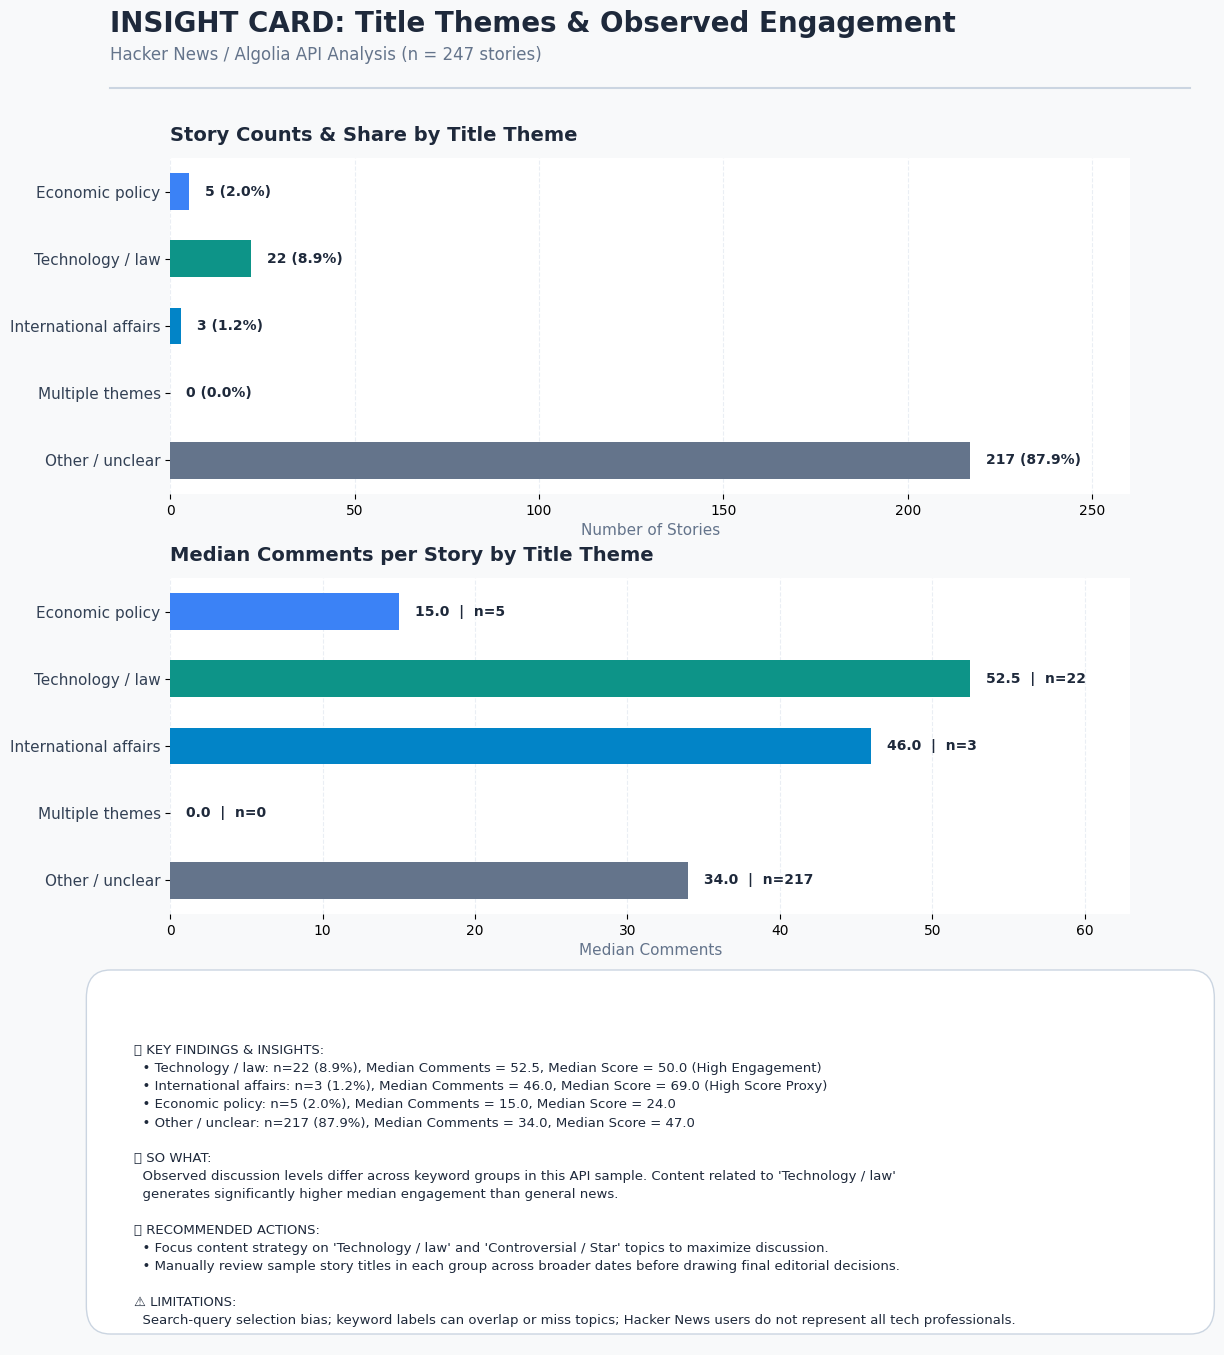

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---------------------------------------------------------
# 1. เตรียมข้อมูลจากผลการวิเคราะห์ (จากภาพตัวอย่าง)
# ---------------------------------------------------------
data = {
    'theme': ['Economic policy', 'Technology / law', 'International affairs', 'Multiple themes', 'Other / unclear'],
    'stories': [5, 22, 3, 0, 217],
    'share_pct': [2.0, 8.9, 1.2, 0.0, 87.9],
    'median_comments': [15.0, 52.5, 46.0, 0.0, 34.0],
    'median_score': [24.0, 50.0, 69.0, 0.0, 47.0],
    'total_comments': [69, 3305, 176, 0, 18849]
}

theme_table = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. ตั้งค่า Styling และ Layout สำหรับ Insight Card
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "savefig.dpi": 300
})

# สร้าง Canvas แบบ Multi-panel
fig = plt.figure(figsize=(12, 14), facecolor='#F8F9FA')

# ตกแต่ง Header ของ Insight Card
fig.text(0.05, 0.95, "INSIGHT CARD: Title Themes & Observed Engagement",
         fontsize=20, fontweight='bold', color='#1E293B')
fig.text(0.05, 0.93, "Hacker News / Algolia API Analysis (n = 247 stories)",
         fontsize=12, color='#64748B')

# Line divider
line = plt.Line2D([0.05, 0.95], [0.91, 0.91], transform=fig.transFigure, color='#CBD5E1', linewidth=1.5)
fig.lines.append(line)

# ---------------------------------------------------------
# 3. สร้าง กราฟแท่ง (Bar Charts) 2 กราฟ
# ---------------------------------------------------------
colors = ["#3B82F6", "#0D9488", "#0284C7", "#94A3B8", "#64748B"]

# --- Subplot 1: Story Counts ---
ax1 = fig.add_axes([0.1, 0.62, 0.8, 0.24]) # [left, bottom, width, height]
ax1.set_facecolor("white")
ax1.set_title("Story Counts & Share by Title Theme", loc="left", fontsize=14, fontweight="bold", color="#1E293B", pad=12)

y_pos = np.arange(len(theme_table))[::-1]
bars1 = ax1.barh(y_pos, theme_table['stories'], height=0.55, color=colors, edgecolor="none")

ax1.set_yticks(y_pos)
ax1.set_yticklabels(theme_table['theme'], fontsize=11, color="#334155")
ax1.set_xlabel("Number of Stories", color="#64748B", fontsize=11)
ax1.grid(axis="x", color="#E2E8F0", linestyle="--", alpha=0.7)
ax1.set_axisbelow(True)

for spine in ax1.spines.values():
    spine.set_visible(False)

# ใส่ตัวเลขแสดงค่าปลายแท่งกราฟ
max_val1 = theme_table['stories'].max()
ax1.set_xlim(0, max_val1 * 1.2)
for i, (count, pct) in enumerate(zip(theme_table['stories'], theme_table['share_pct'])):
    ax1.text(count + (max_val1 * 0.02), y_pos[i], f"{count} ({pct:.1f}%)",
             va='center', ha='left', fontweight='bold', color="#1E293B", fontsize=10)


# --- Subplot 2: Median Comments ---
ax2 = fig.add_axes([0.1, 0.32, 0.8, 0.24])
ax2.set_facecolor("white")
ax2.set_title("Median Comments per Story by Title Theme", loc="left", fontsize=14, fontweight="bold", color="#1E293B", pad=12)

bars2 = ax2.barh(y_pos, theme_table['median_comments'], height=0.55, color=colors, edgecolor="none")

ax2.set_yticks(y_pos)
ax2.set_yticklabels(theme_table['theme'], fontsize=11, color="#334155")
ax2.set_xlabel("Median Comments", color="#64748B", fontsize=11)
ax2.grid(axis="x", color="#E2E8F0", linestyle="--", alpha=0.7)
ax2.set_axisbelow(True)

for spine in ax2.spines.values():
    spine.set_visible(False)

# ใส่ตัวเลขแสดงค่าปลายแท่งกราฟ
max_val2 = theme_table['median_comments'].max()
ax2.set_xlim(0, max_val2 * 1.2)
for i, (med, count) in enumerate(zip(theme_table['median_comments'], theme_table['stories'])):
    ax2.text(med + (max_val2 * 0.02), y_pos[i], f"{med:.1f}  |  n={count}",
             va='center', ha='left', fontweight='bold', color="#1E293B", fontsize=10)

# ---------------------------------------------------------
# 4. ส่วนสรุป Insight & Executive Summary ด้านล่าง
# ---------------------------------------------------------
summary_box = patches.FancyBboxPatch((0.05, 0.04), 0.9, 0.22, transform=fig.transFigure,
                                     boxstyle="round,pad=0.02", facecolor="white", edgecolor="#CBD5E1", linewidth=1)
fig.patches.append(summary_box)

# ข้อความ Insight / Action / Limitation
insight_text = """
📌 KEY FINDINGS & INSIGHTS:
  • Technology / law: n=22 (8.9%), Median Comments = 52.5, Median Score = 50.0 (High Engagement)
  • International affairs: n=3 (1.2%), Median Comments = 46.0, Median Score = 69.0 (High Score Proxy)
  • Economic policy: n=5 (2.0%), Median Comments = 15.0, Median Score = 24.0
  • Other / unclear: n=217 (87.9%), Median Comments = 34.0, Median Score = 47.0

💡 SO WHAT:
  Observed discussion levels differ across keyword groups in this API sample. Content related to 'Technology / law'
  generates significantly higher median engagement than general news.

🎯 RECOMMENDED ACTIONS:
  • Focus content strategy on 'Technology / law' and 'Controversial / Star' topics to maximize discussion.
  • Manually review sample story titles in each group across broader dates before drawing final editorial decisions.

⚠️ LIMITATIONS:
  Search-query selection bias; keyword labels can overlap or miss topics; Hacker News users do not represent all tech professionals.
"""

fig.text(0.07, 0.24, insight_text, fontsize=9.5, color="#1E293B", verticalalignment='top', linespacing=1.5)

# แสดงผลกราฟ
plt.show()

---
# เกณฑ์การให้คะแนน (Rubric) — 100 คะแนน + Bonus สูงสุด 5 คะแนน

คะแนนเน้น **ความถูกต้อง + Insight + ประโยชน์ต่อการตัดสินใจ** มากกว่าจำนวนเทคนิค

## Part 1 — Individual Warm-up (10 คะแนน)

| เกณฑ์ | คะแนน |
|---|---:|
| ตอบ 4 คำถามหลักถูกต้อง | 6 |
| Data handling / reproducibility | 2 |
| การตีความและข้อจำกัด | 2 |

## Part 2 — Voice of Customer / Business Insight (50 คะแนน)

| เกณฑ์ | คะแนน | สิ่งที่ดู |
|---|---:|---|
| **Data preparation** | 8 | sampling, join, missing/duplicate และข้อจำกัด |
| **EDA ที่เกี่ยวกับโจทย์** | 7 | สำรวจเท่าที่จำเป็นและใช้ต่อยอดคำถามได้ |
| **Text features + เทคนิค** | 10 | อย่างน้อย 2 features, วิธีถูกและเหมาะกับ brief |
| **Insight & Business usefulness** | **15** | Insight Card 2 ใบ มีหลักฐาน So what และ Action |
| **Reality Check / ความถูกต้องของข้อสรุป** | 6 | ตรวจ alternative explanation อย่างน้อย 1 insight |
| **Visualization + reproducibility** | 4 | กราฟชัด โค้ดและผลตรวจตามได้ |

## Part 3 — Data Collection Robot + External Insight (25 คะแนน)

| เกณฑ์ | คะแนน | สิ่งที่ดู |
|---|---:|---|
| **คำถามและประโยชน์** | 5 | รู้ว่าจะเก็บไปตอบอะไร |
| **แหล่งข้อมูล + วิธีเก็บ** | 5 | Robot/API/RSS เหมาะสมและรับผิดชอบ |
| **Data quality** | 5 | อย่างน้อย 200 valid records และตรวจคุณภาพ |
| **Technique correctness** | 4 | ใช้ 1–2 เทคนิคที่เหมาะและคำนวณถูก |
| **Insight + limitation** | 6 | มีหลักฐาน, Action และไม่ overclaim |

## การนำเสนอและ Q&A (15 คะแนน)

| เกณฑ์ | คะแนน |
|---|---:|
| Storyline + เวลา | 4 |
| Visualization / การสื่อสารผล | 3 |
| อธิบายเหตุผลของวิธีวิเคราะห์ | 3 |
| **Q&A ในส่วนที่ตนรับผิดชอบ (รายบุคคล)** | **5** |

> คะแนน Part 2–3 เป็นคะแนนทีม แต่ Q&A 5 คะแนนคิดเป็นรายบุคคล

---
## Bonus สูงสุด +5 คะแนน

| Bonus | สูงสุด | ตัวอย่าง |
|---|---:|---|
| **Creativity / interesting question** | +2 | มุมวิเคราะห์ใหม่หรือเชื่อมข้อมูลได้ดี |
| **Advanced technique ที่ใช้ถูกและอธิบายได้** | +2 | topic model, embedding, regression, clustering ฯลฯ |
| **Exceptional business value** | +1 | ประมาณ impact, สร้าง priority score/KPI หรือ insight เพิ่มที่ใช้ตัดสินใจได้จริง |

> เทคนิคยากแต่ใช้ผิดหรืออธิบายไม่ได้ **ไม่ได้ Bonus**


---
# เสร็จแล้ววววว 🥳

## สิ่งที่ต้องส่ง

### A. Part 1 — งานเดี่ยว
นักศึกษาทุกคนส่ง Notebook Part 1 ของตนเอง

### B. Part 2 + Part 3 — งานกลุ่ม
ส่งเพียง **1 คนต่อทีม**
* Notebook งานกลุ่มพร้อมผลรัน
* ถ้า RAM/ไฟล์ใหญ่ แยกเป็น `TeamXX_Part2.ipynb` และ `TeamXX_Part3.ipynb` ได้
* ไฟล์ `corpus.jsonl`/CSV ที่สร้างใน Part 3
* ระบุว่าใครรับผิดชอบส่วนใด

### C. สไลด์นำเสนอ 10 นาที + Q&A

โครงเรื่องแนะนำ:
1. Business question / Client brief
2. ข้อมูลและสิ่งสำคัญจาก EDA
3. **Insight 1**
4. **Insight 2**
5. Reality Check
6. Part 3: Robot/API + External Insight
7. Limitation + Action
8. AI usage

ไม่ต้องใส่ source code ลงสไลด์

### Q&A
อาจารย์ถามสมาชิกแต่ละคนใน **ส่วนที่ตนรับผิดชอบ** ว่าทำอะไร ทำไมเลือกวิธีนี้ ผลหมายถึงอะไร และมีข้อจำกัดอะไร

> เป้าหมายของงานนี้คือ **ทำ analytics ให้ถูกและเกิด insight** ไม่ใช่ทำ technique ให้เยอะที่สุด
